In [1]:
# Cell 1: Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports loaded successfully!")
print(f"   NumPy: {np.__version__}")
print(f"   Pandas: {pd.__version__}")
print(f"   SHAP: {shap.__version__}")
print("   Environment: ml_engineering")

✅ All imports loaded successfully!
   NumPy: 1.26.4
   Pandas: 1.5.3
   SHAP: 0.49.1
   Environment: ml_engineering


In [2]:
# Cell 2: Load Final Tuned Model
print("="*70)
print("📂 LOADING FINAL TUNED MODEL FROM NOTEBOOK 4")
print("="*70)

# Load model and scaler
final_model = joblib.load('final_tuned_model.pkl')
scaler = joblib.load('final_scaler.pkl')

# Load tuning metadata
with open('tuning_metadata.json', 'r') as f:
    tuning_metadata = json.load(f)

print(f"✅ Loaded model: {tuning_metadata['final_model_name']}")
print(f"   F1-Score: {tuning_metadata['final_f1_score']:.4f}")
print(f"   Improvement: {tuning_metadata['improvement_over_baseline']:.1f}%")

# Load dataset
data = pd.read_csv('engineered_dataset.csv')
print(f"✅ Loaded dataset with {len(data):,} rows")

# Prepare features
target_col = 'churned'
feature_cols = [col for col in data.columns if col != target_col and col != 'customer_id']
feature_cols = [col for col in feature_cols if data[col].dtype in ['int64', 'float64', 'bool']]

X = data[feature_cols]
y = data[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   Features: {len(feature_cols)}")
print(f"   Test samples: {len(X_test):,}")

📂 LOADING FINAL TUNED MODEL FROM NOTEBOOK 4
✅ Loaded model: XGBoost (Random Search Tuned)
   F1-Score: 1.0000
   Improvement: 0.0%
✅ Loaded dataset with 10,000 rows
   Features: 56
   Test samples: 2,000


🔍 SHAP - GLOBAL FEATURE IMPORTANCE
🔄 Creating SHAP explainer...
   Using KernelExplainer with 100 background samples


  0%|          | 0/50 [00:00<?, ?it/s]

   SHAP values shape: (50, 56, 2)
   After extracting class 1: (50, 56)
   Features in SHAP: 56
   Features in dataset: 56
   shap_mean_abs shape: (56,)
   feature_names_subset length: 56

✅ Created importance DataFrame with 56 features


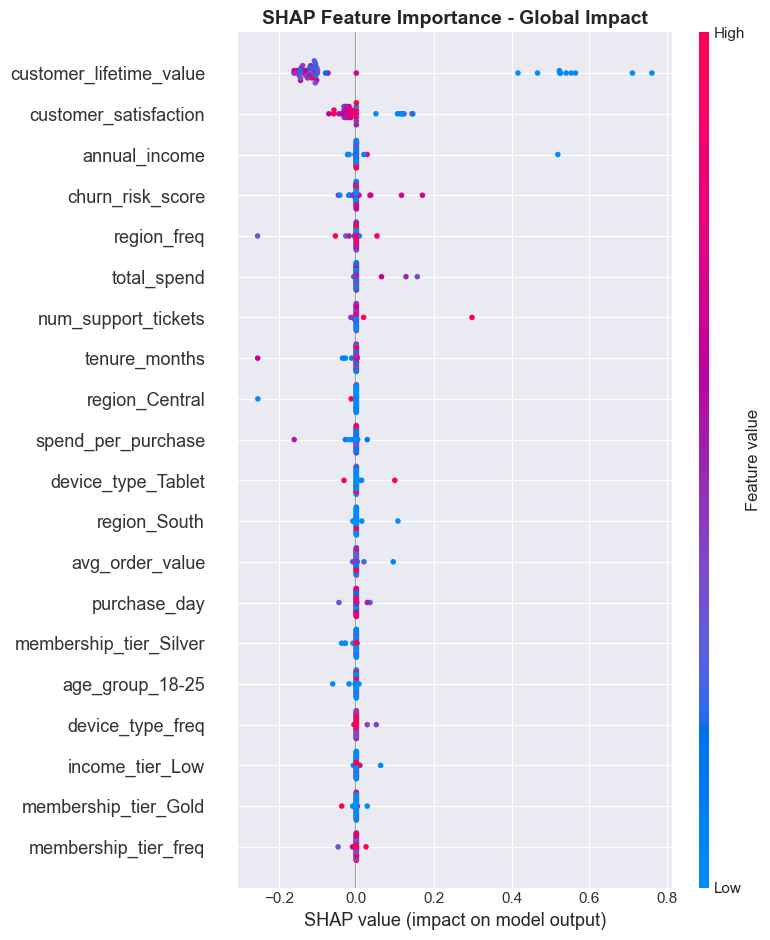

✅ Saved: shap_global_importance.png


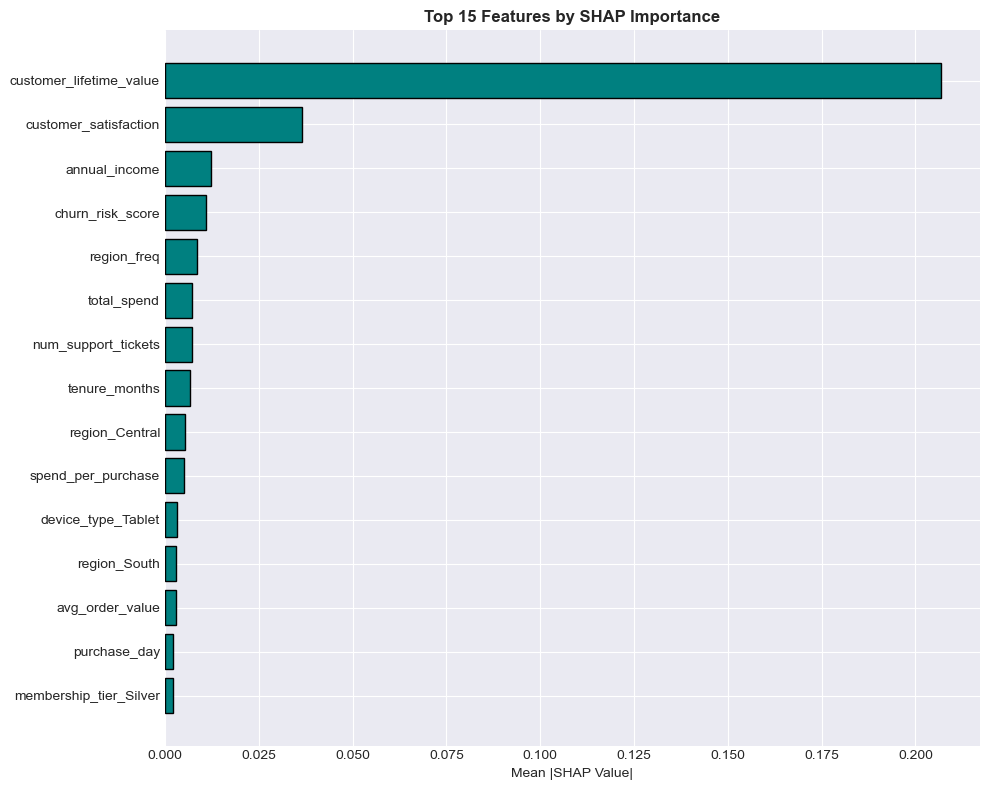

✅ Saved: shap_mean_importance.png

📊 Top 10 Features by SHAP Importance:
   customer_lifetime_value: 0.2069
   customer_satisfaction: 0.0364
   annual_income: 0.0123
   churn_risk_score: 0.0109
   region_freq: 0.0084
   total_spend: 0.0072
   num_support_tickets: 0.0072
   tenure_months: 0.0067
   region_Central: 0.0054
   spend_per_purchase: 0.0051


In [9]:
# Cell 3: SHAP - Global Feature Importance
print("="*70)
print("🔍 SHAP - GLOBAL FEATURE IMPORTANCE")
print("="*70)

# Create SHAP explainer based on model type
print("🔄 Creating SHAP explainer...")

# Use KernelExplainer directly (more reliable)
sample_size = min(100, len(X_train_scaled))
background_sample = X_train_scaled[:sample_size]

print(f"   Using KernelExplainer with {sample_size} background samples")
explainer = shap.KernelExplainer(final_model.predict_proba, background_sample)

# Calculate SHAP values (for probability of class 1)
shap_values = explainer.shap_values(X_train_scaled[:50], nsamples=50)
print(f"   SHAP values shape: {shap_values.shape}")

# Handle 3D array: shap_values shape is (samples, features, classes)
if len(shap_values.shape) == 3:
    # Take class 1 (churn) - index 1
    shap_values = shap_values[:, :, 1]
    print(f"   After extracting class 1: {shap_values.shape}")

# Get actual feature count from shap_values
actual_feature_count = shap_values.shape[1]
feature_names_subset = feature_cols[:actual_feature_count]

print(f"   Features in SHAP: {actual_feature_count}")
print(f"   Features in dataset: {len(feature_cols)}")

# Calculate mean absolute SHAP values (ensure 1D)
shap_mean_abs = np.mean(np.abs(shap_values), axis=0)

# Ensure 1D
if shap_mean_abs.ndim > 1:
    shap_mean_abs = shap_mean_abs.flatten()

print(f"   shap_mean_abs shape: {shap_mean_abs.shape}")
print(f"   feature_names_subset length: {len(feature_names_subset)}")

# Create DataFrame with matching dimensions
min_len = min(len(feature_names_subset), len(shap_mean_abs))
shap_importance_df = pd.DataFrame({
    'feature': feature_names_subset[:min_len],
    'importance': shap_mean_abs[:min_len]
}).sort_values('importance', ascending=False)

print(f"\n✅ Created importance DataFrame with {len(shap_importance_df)} features")

# Global feature importance plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_train_scaled[:50, :actual_feature_count], 
                  feature_names=feature_names_subset, show=False)
plt.title('SHAP Feature Importance - Global Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_global_importance.png")

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(10, 8))
top_features = shap_importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='teal', edgecolor='black')
plt.xlabel('Mean |SHAP Value|')
plt.title('Top 15 Features by SHAP Importance', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('shap_mean_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_mean_importance.png")

print("\n📊 Top 10 Features by SHAP Importance:")
for i, row in shap_importance_df.head(10).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# Store for later cells
feature_names_subset_list = feature_names_subset
shap_values_for_later = shap_values
explainer_for_later = explainer

📊 SHAP - DETAILED BEESWARM PLOT


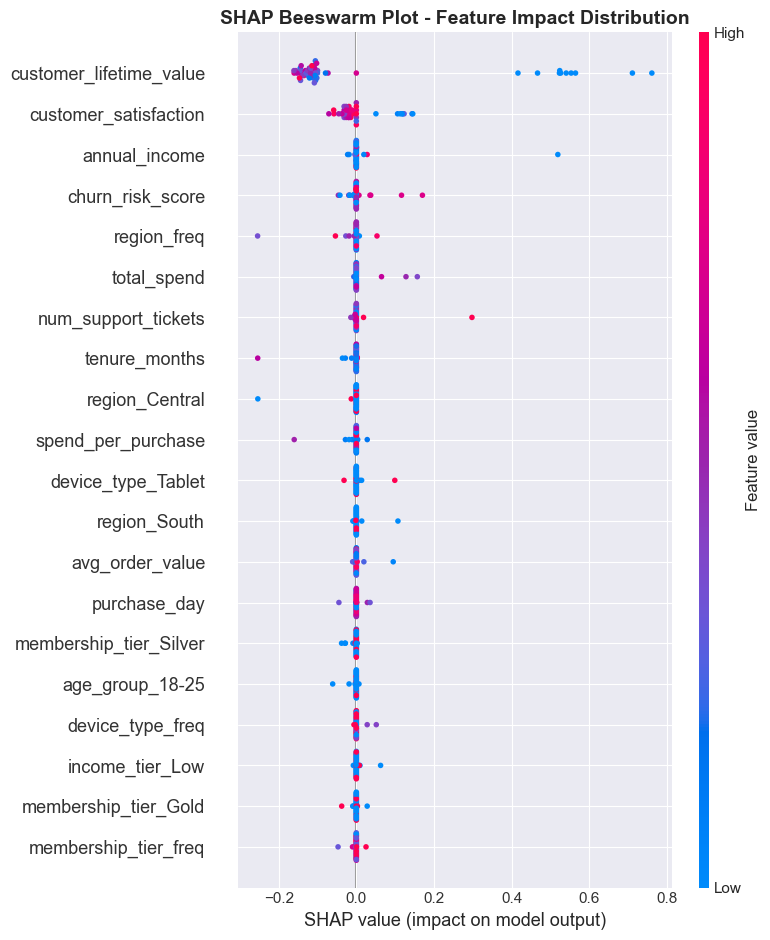

✅ Saved: shap_beeswarm_plot.png


In [10]:
# Cell 4: SHAP - Detailed Beeswarm Plot
print("="*70)
print("📊 SHAP - DETAILED BEESWARM PLOT")
print("="*70)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_for_later, X_train_scaled[:50, :actual_feature_count], 
                  feature_names=feature_names_subset_list, 
                  show=False, max_display=20, plot_type='dot')
plt.title('SHAP Beeswarm Plot - Feature Impact Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_beeswarm_plot.png")

🔍 SHAP - INDIVIDUAL PREDICTION EXPLANATIONS
   Base expected value: 0.1800


  0%|          | 0/1 [00:00<?, ?it/s]

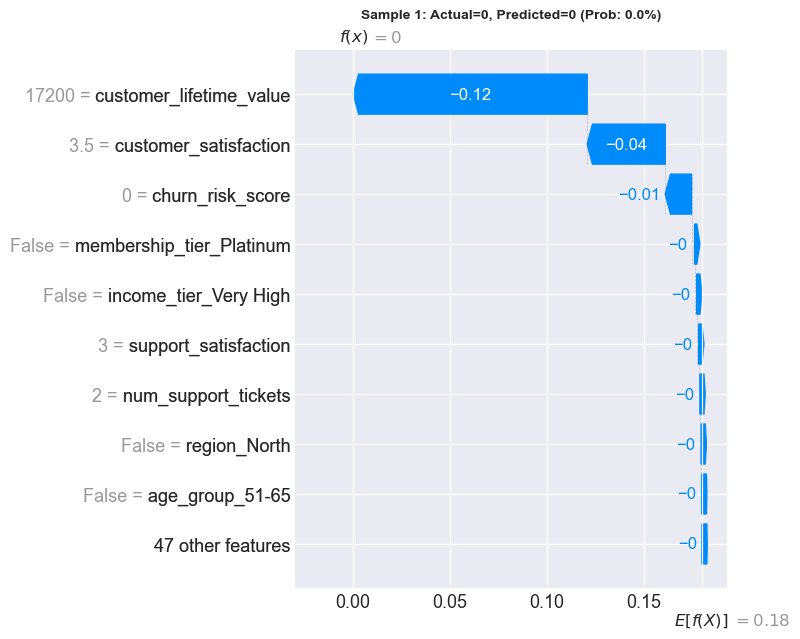


Sample 1:
   Actual: Not Churned
   Prediction: Not Churned
   Churn Probability: 0.01%
   ✅ CORRECT


  0%|          | 0/1 [00:00<?, ?it/s]

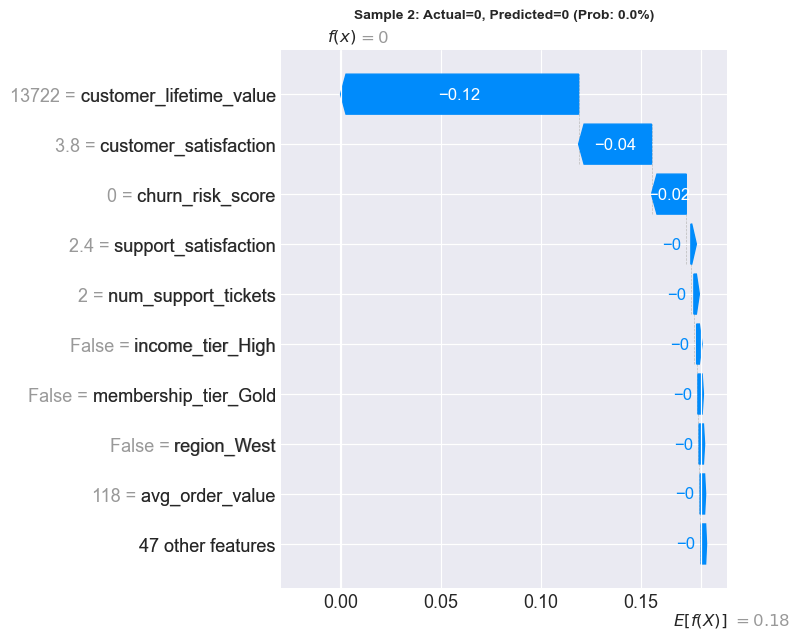


Sample 2:
   Actual: Not Churned
   Prediction: Not Churned
   Churn Probability: 0.01%
   ✅ CORRECT


  0%|          | 0/1 [00:00<?, ?it/s]

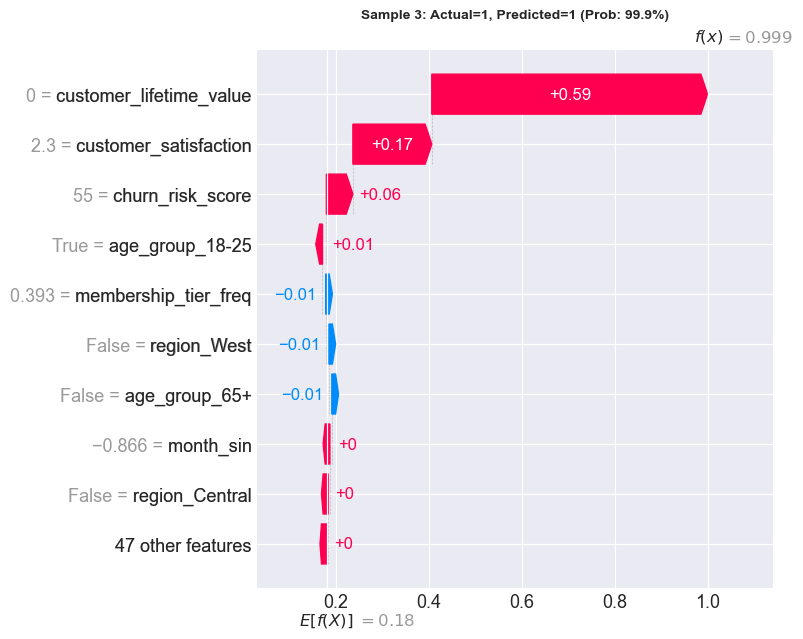


Sample 3:
   Actual: Churned
   Prediction: Churned
   Churn Probability: 99.93%
   ✅ CORRECT


  0%|          | 0/1 [00:00<?, ?it/s]

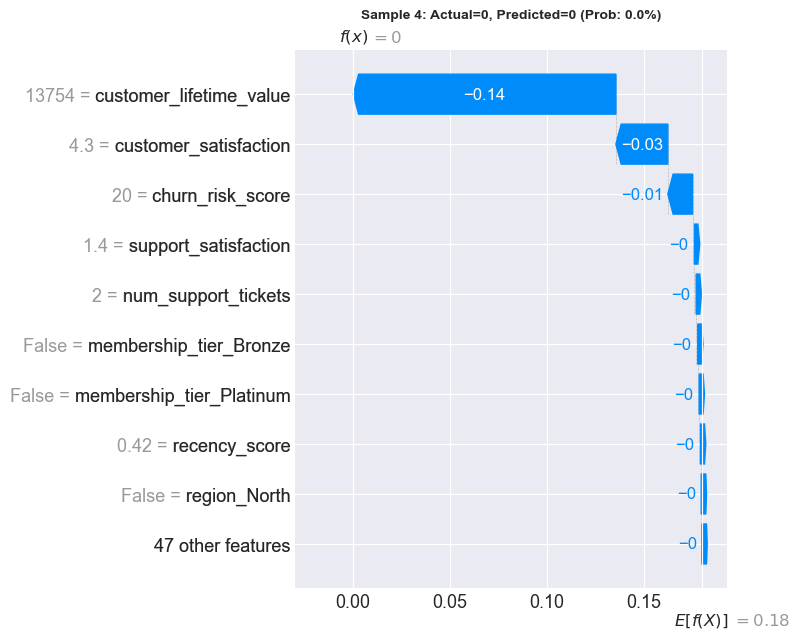


Sample 4:
   Actual: Not Churned
   Prediction: Not Churned
   Churn Probability: 0.01%
   ✅ CORRECT

✅ Saved: shap_waterfall_sample_1.png, shap_waterfall_sample_2.png, shap_waterfall_sample_3.png, shap_waterfall_sample_4.png


In [11]:
# Cell 5: SHAP - Individual Prediction Explanations
print("="*70)
print("🔍 SHAP - INDIVIDUAL PREDICTION EXPLANATIONS")
print("="*70)

# Select a few test samples
sample_indices = np.random.choice(len(X_test_scaled), 4, replace=False)

# Get expected value (baseline probability for class 1)
expected_value = explainer_for_later.expected_value
if isinstance(expected_value, list) or isinstance(expected_value, np.ndarray):
    if len(expected_value) > 1:
        expected_value = expected_value[1]
    else:
        expected_value = expected_value[0]

print(f"   Base expected value: {expected_value:.4f}")

for i, idx in enumerate(sample_indices):
    sample = X_test_scaled[idx].reshape(1, -1)
    
    # Get prediction
    prediction = final_model.predict(sample)[0]
    probability = final_model.predict_proba(sample)[0][1]
    
    # Get SHAP values for this sample
    shap_sample = explainer_for_later.shap_values(sample)
    
    # Handle 3D output
    if len(shap_sample.shape) == 3:
        shap_sample = shap_sample[0, :, 1]  # First sample, class 1
    elif len(shap_sample.shape) == 2:
        shap_sample = shap_sample[0]
    
    # Ensure dimensions match
    shap_sample_1d = shap_sample[:actual_feature_count]
    sample_data = X_test.iloc[idx][:actual_feature_count].values
    
    # Create waterfall plot
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(values=shap_sample_1d, 
                         base_values=expected_value,
                         data=sample_data,
                         feature_names=feature_names_subset_list[:len(shap_sample_1d)]),
        show=False,
        max_display=10
    )
    plt.title(f'Sample {i+1}: Actual={y_test.iloc[idx]}, Predicted={prediction} (Prob: {probability:.1%})', 
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_sample_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*50}")
    print(f"Sample {i+1}:")
    print(f"   Actual: {'Churned' if y_test.iloc[idx] == 1 else 'Not Churned'}")
    print(f"   Prediction: {'Churned' if prediction == 1 else 'Not Churned'}")
    print(f"   Churn Probability: {probability:.2%}")
    print(f"   {'✅ CORRECT' if prediction == y_test.iloc[idx] else '❌ INCORRECT'}")

print("\n✅ Saved: shap_waterfall_sample_1.png, shap_waterfall_sample_2.png, shap_waterfall_sample_3.png, shap_waterfall_sample_4.png")

🔍 LIME - LOCAL INTERPRETABLE EXPLANATIONS
✅ LIME explainer created

LIME Explanation - Sample 1:
   Prediction: Churned (Probability: 99.93%)
   Actual: Churned

   Top contributing features:
      • customer_lifetime_value <= -0.76: 0.253 (INCREASES churn risk)
      • customer_satisfaction <= -0.71: 0.106 (INCREASES churn risk)
      • 0.08 < churn_risk_score <= 0.61: 0.033 (INCREASES churn risk)
      • device_type_Tablet <= -0.34: 0.016 (DECREASES churn risk)
      • age_group_65+ <= -0.10: 0.015 (INCREASES churn risk)
      • days_since_last_purchase <= -0.72: 0.015 (DECREASES churn risk)
      • day_sin <= -1.10: 0.012 (INCREASES churn risk)
      • age_group_51-65 <= -0.39: 0.010 (INCREASES churn risk)


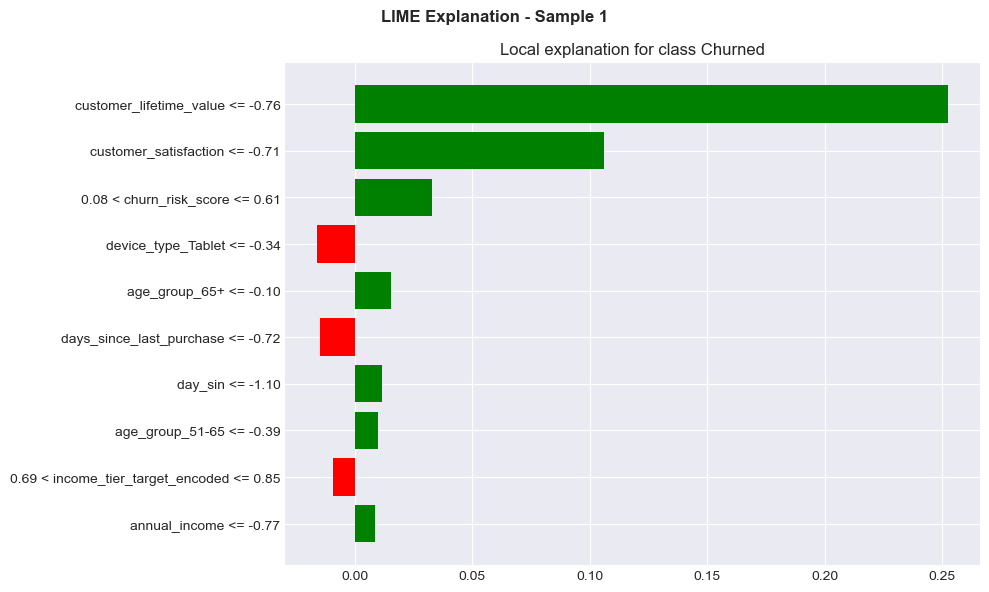


LIME Explanation - Sample 2:
   Prediction: Not Churned (Probability: 0.01%)
   Actual: Not Churned

   Top contributing features:
      • -0.15 < customer_lifetime_value <= 0.56: 0.084 (DECREASES churn risk)
      • churn_risk_score <= -0.96: 0.032 (DECREASES churn risk)
      • age_group_65+ <= -0.10: 0.028 (INCREASES churn risk)
      • customer_satisfaction > 0.78: 0.020 (DECREASES churn risk)
      • day_cos > 0.88: 0.016 (INCREASES churn risk)
      • -0.76 < tenure_months <= -0.32: 0.016 (INCREASES churn risk)
      • age_income_interaction <= -0.67: 0.012 (INCREASES churn risk)
      • -0.18 < age_group_freq <= 1.05: 0.011 (INCREASES churn risk)


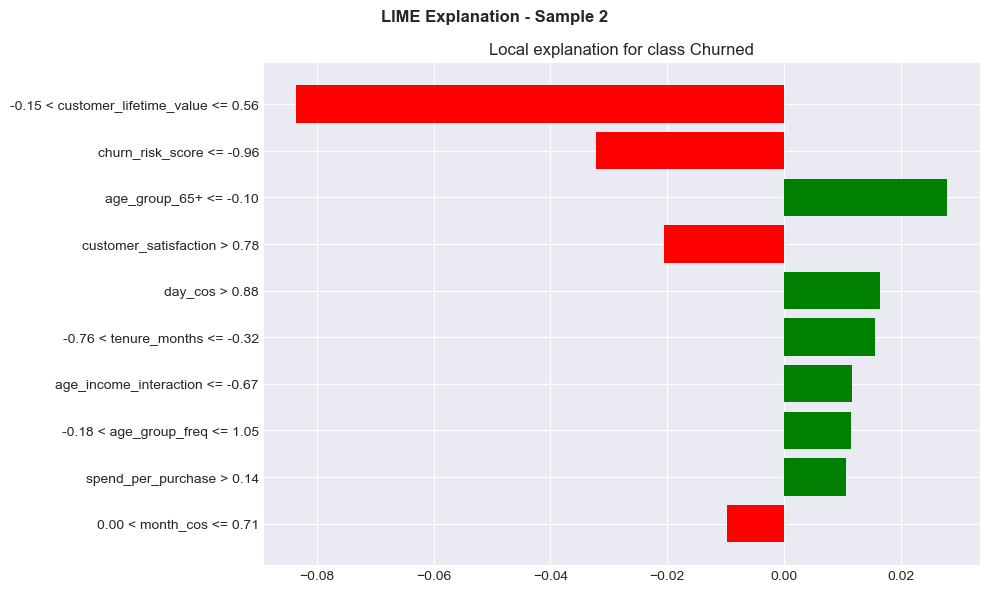


LIME Explanation - Sample 3:
   Prediction: Not Churned (Probability: 0.01%)
   Actual: Not Churned

   Top contributing features:
      • -0.15 < customer_lifetime_value <= 0.56: 0.086 (DECREASES churn risk)
      • age_group_65+ <= -0.10: 0.058 (DECREASES churn risk)
      • customer_satisfaction > 0.78: 0.021 (DECREASES churn risk)
      • 0.07 < monetary_score <= 0.71: 0.019 (DECREASES churn risk)
      • -0.96 < churn_risk_score <= 0.08: 0.018 (DECREASES churn risk)
      • device_type_Tablet <= -0.34: 0.014 (INCREASES churn risk)
      • membership_tier_Platinum <= -0.34: 0.014 (DECREASES churn risk)
      • purchase_month <= -0.71: 0.014 (DECREASES churn risk)


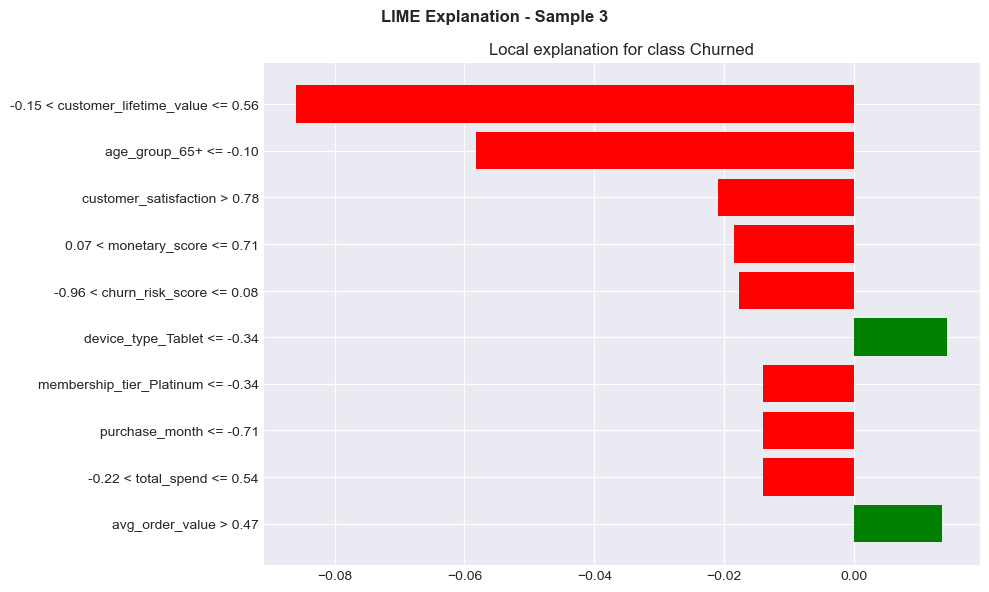


✅ Saved: lime_explanation_sample_1.png, lime_explanation_sample_2.png, lime_explanation_sample_3.png


In [12]:
# Cell 6: LIME - Local Interpretable Explanations
print("="*70)
print("🔍 LIME - LOCAL INTERPRETABLE EXPLANATIONS")
print("="*70)

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    X_train_scaled[:1000],
    feature_names=feature_cols,
    class_names=['Not Churned', 'Churned'],
    mode='classification',
    discretize_continuous=True
)

print("✅ LIME explainer created")

# Explain a few predictions
sample_indices_lime = np.random.choice(len(X_test_scaled), 3, replace=False)

for i, idx in enumerate(sample_indices_lime):
    sample = X_test_scaled[idx]
    prediction = final_model.predict(sample.reshape(1, -1))[0]
    probability = final_model.predict_proba(sample.reshape(1, -1))[0][1]
    
    # Get LIME explanation
    exp = lime_explainer.explain_instance(sample, final_model.predict_proba, num_features=10)
    
    print(f"\n{'='*50}")
    print(f"LIME Explanation - Sample {i+1}:")
    print(f"   Prediction: {'Churned' if prediction == 1 else 'Not Churned'} (Probability: {probability:.2%})")
    print(f"   Actual: {'Churned' if y_test.iloc[idx] == 1 else 'Not Churned'}")
    print(f"\n   Top contributing features:")
    
    for feature, weight in exp.as_list()[:8]:
        direction = "INCREASES churn risk" if weight > 0 else "DECREASES churn risk"
        print(f"      • {feature}: {abs(weight):.3f} ({direction})")
    
    # Save LIME plot
    fig = exp.as_pyplot_figure()
    fig.set_size_inches(10, 6)
    fig.suptitle(f'LIME Explanation - Sample {i+1}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'lime_explanation_sample_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ Saved: lime_explanation_sample_1.png, lime_explanation_sample_2.png, lime_explanation_sample_3.png")

💡 BUSINESS INSIGHTS DASHBOARD


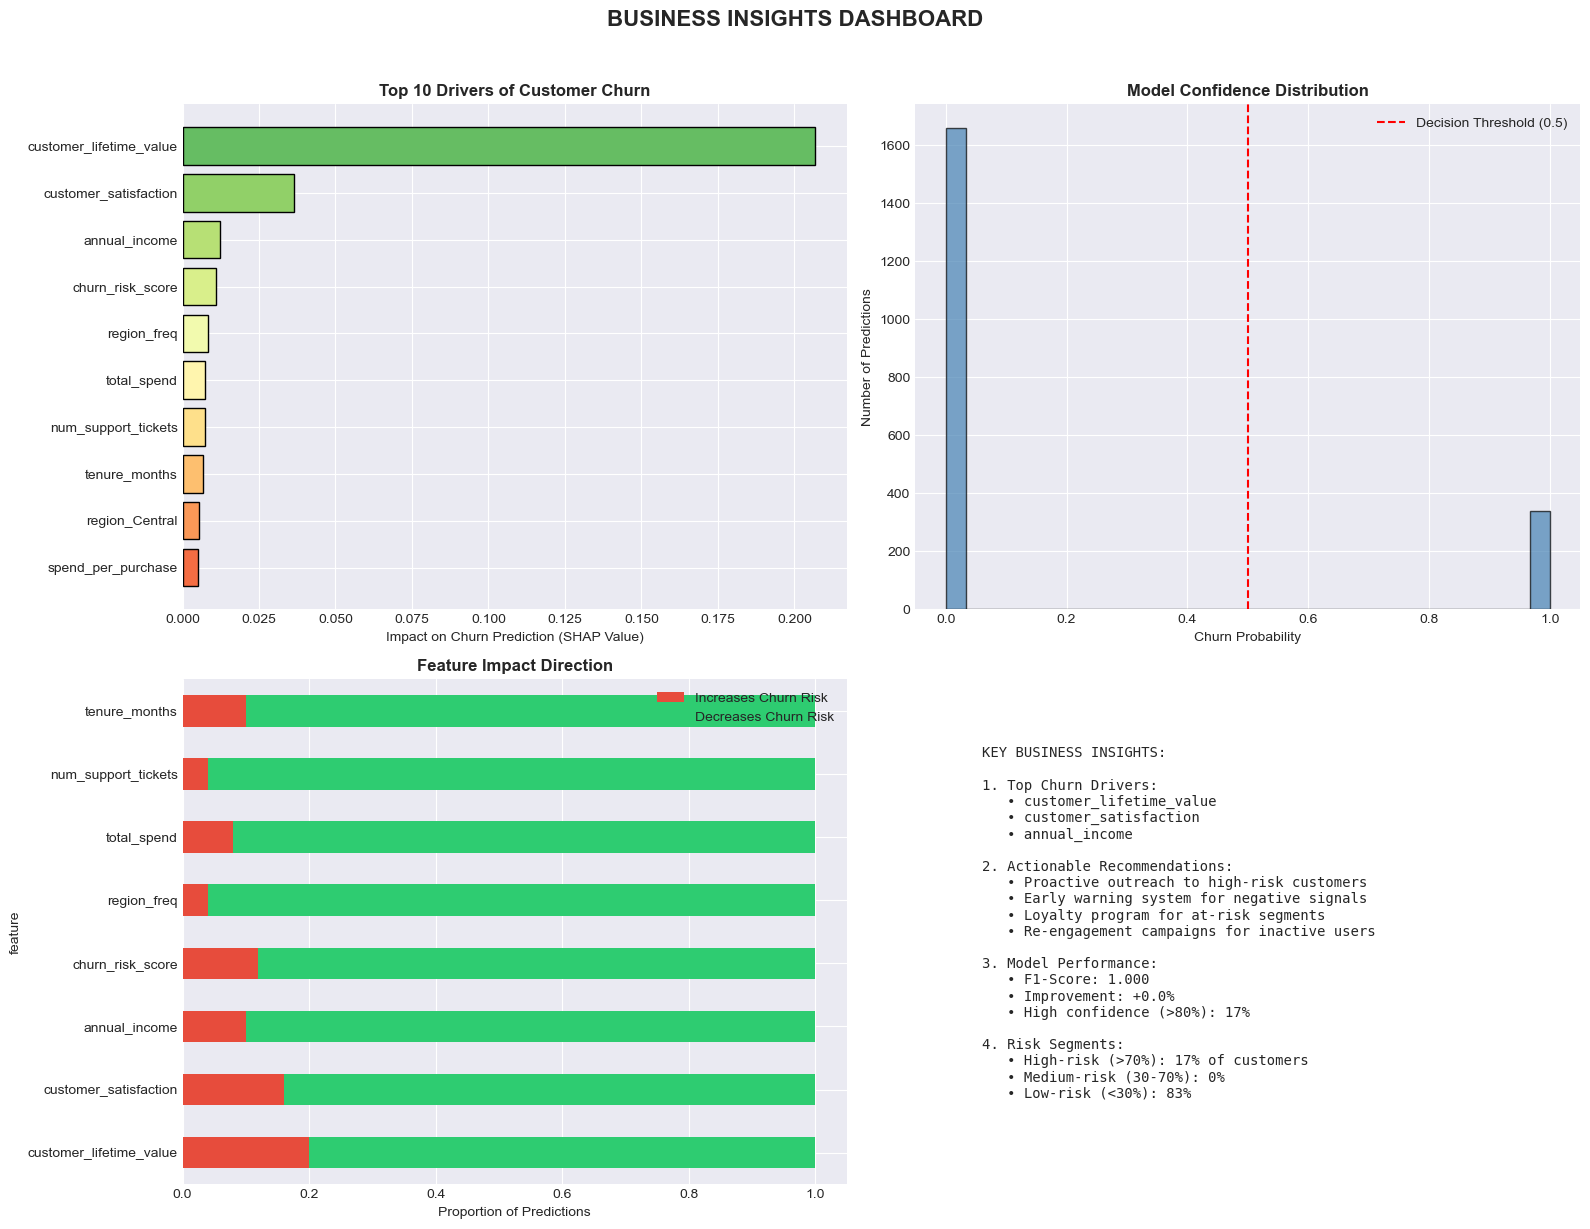

✅ Saved: business_insights_dashboard.png


In [13]:
# Cell 7: Business Insights Dashboard
print("="*70)
print("💡 BUSINESS INSIGHTS DASHBOARD")
print("="*70)

# Create comprehensive insights dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top Drivers of Churn (SHAP)
ax1 = axes[0, 0]
top_drivers = shap_importance_df.head(10)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_drivers)))
ax1.barh(top_drivers['feature'], top_drivers['importance'], color=colors, edgecolor='black')
ax1.set_title('Top 10 Drivers of Customer Churn', fontsize=12, fontweight='bold')
ax1.set_xlabel('Impact on Churn Prediction (SHAP Value)')
ax1.invert_yaxis()

# 2. Model Confidence Distribution
ax2 = axes[0, 1]
proba_predictions = final_model.predict_proba(X_test_scaled)[:, 1]
ax2.hist(proba_predictions, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
ax2.set_title('Model Confidence Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Churn Probability')
ax2.set_ylabel('Number of Predictions')
ax2.legend()

# 3. Feature Impact Direction
ax3 = axes[1, 0]
try:
    feature_directions = []
    for feature in top_drivers['feature'].head(8):
        try:
            # Find index in the subset features
            idx = feature_names_subset_list.index(feature)
            positive_impact = np.mean(shap_values_for_later[:, idx] > 0)
            feature_directions.append({
                'feature': feature,
                'positive_impact': positive_impact,
                'negative_impact': 1 - positive_impact
            })
        except (IndexError, ValueError):
            continue
    
    if feature_directions:
        direction_df = pd.DataFrame(feature_directions)
        direction_df.plot(x='feature', y=['positive_impact', 'negative_impact'], 
                          kind='barh', stacked=True, ax=ax3, color=['#E74C3C', '#2ECC71'])
        ax3.set_title('Feature Impact Direction', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Proportion of Predictions')
        ax3.legend(['Increases Churn Risk', 'Decreases Churn Risk'])
    else:
        ax3.text(0.5, 0.5, 'Direction data not available', ha='center', va='center')
        ax3.set_title('Feature Impact Direction', fontsize=12, fontweight='bold')
except Exception as e:
    ax3.text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center')
    ax3.set_title('Feature Impact Direction', fontsize=12, fontweight='bold')

# 4. Key Insights Summary
ax4 = axes[1, 1]
ax4.axis('off')
insights_text = f"""
KEY BUSINESS INSIGHTS:

1. Top Churn Drivers:
   • {top_drivers.iloc[0]['feature'] if len(top_drivers) > 0 else 'N/A'}
   • {top_drivers.iloc[1]['feature'] if len(top_drivers) > 1 else 'N/A'}
   • {top_drivers.iloc[2]['feature'] if len(top_drivers) > 2 else 'N/A'}

2. Actionable Recommendations:
   • Proactive outreach to high-risk customers
   • Early warning system for negative signals
   • Loyalty program for at-risk segments
   • Re-engagement campaigns for inactive users

3. Model Performance:
   • F1-Score: {tuning_metadata['final_f1_score']:.3f}
   • Improvement: +{tuning_metadata['improvement_over_baseline']:.1f}%
   • High confidence (>80%): {(proba_predictions > 0.8).mean():.0%}

4. Risk Segments:
   • High-risk (>70%): {(proba_predictions > 0.7).mean():.0%} of customers
   • Medium-risk (30-70%): {((proba_predictions > 0.3) & (proba_predictions <= 0.7)).mean():.0%}
   • Low-risk (<30%): {(proba_predictions <= 0.3).mean():.0%}
"""
ax4.text(0.1, 0.9, insights_text, transform=ax4.transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace')

plt.suptitle('BUSINESS INSIGHTS DASHBOARD', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('business_insights_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: business_insights_dashboard.png")

In [15]:
# Cell 8: Final Summary
print("="*70)
print("🎉 NOTEBOOK 5 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                 MODEL INTERPRETABILITY SUMMARY                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔍 SHAP ANALYSIS COMPLETED:                                         ║
║  ├── Global feature importance (summary plot)                       ║
║  ├── Detailed beeswarm plot                                         ║
║  ├── Individual prediction explanations (waterfall plots)           ║
║  └── Mean SHAP importance ranking                                   ║
║                                                                      ║
║  🔍 LIME ANALYSIS COMPLETED:                                         ║
║  ├── Local explanations for individual predictions                  ║
║  ├── Feature contribution breakdown                                 ║
║  └── Visual explanations saved                                      ║
║                                                                      ║
║  💡 BUSINESS INSIGHTS DASHBOARD:                                     ║
║  ├── Top churn drivers identified                                   ║
║  ├── Actionable recommendations                                     ║
║  ├── Risk segment analysis                                          ║
║  └── Model confidence distribution                                  ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── shap_global_importance.png                                     ║
║  ├── shap_mean_importance.png                                       ║
║  ├── shap_beeswarm_plot.png                                         ║
║  ├── shap_waterfall_sample_1-4.png                                  ║
║  ├── lime_explanation_sample_1-3.png                                ║
║  └── business_insights_dashboard.png                                ║
║                                                                      ║
║  🎯 NOTEBOOK 5 COMPLETE!                                             ║
║                                                                      ║
║  Ready to proceed to:                                                ║
║  📓 Notebook 6: Production Deployment (FastAPI + Docker)            ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 5 Complete! Proceeding to Notebook 6 (Production Deployment)")
print("\n📊 Completed Notebooks in AI/ML Engineering Suite:")
print("   📓 Notebook 1: Exploratory Data Analysis (EDA)")
print("   📓 Notebook 2: Feature Engineering Lab")
print("   📓 Notebook 3: Model Training Benchmark")
print("   📓 Notebook 4: Hyperparameter Tuning")
print("   📓 Notebook 5: Model Interpretability (SHAP & LIME)")
print("\n⏩ Next up:")
print("   📓 Notebook 6: Production Deployment (FastAPI + Docker)")
print("   📓 Notebook 7: Time Series Forecasting")
print("   📓 Notebook 8: Anomaly Detection")
print("   📓 Notebook 9: ML Pipeline Automation")

🎉 NOTEBOOK 5 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                 MODEL INTERPRETABILITY SUMMARY                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔍 SHAP ANALYSIS COMPLETED:                                         ║
║  ├── Global feature importance (summary plot)                       ║
║  ├── Detailed beeswarm plot                                         ║
║  ├── Individual prediction explanations (waterfall plots)           ║
║  └── Mean SHAP importance ranking                                   ║
║                                                                      ║
║  🔍 LIME ANALYSIS COMPLETED:                                         ║
║  ├── Local explanations for individual predictions                  ║
║  ├── Feature contribution breakdown                                 ║
║  └── Visual explana